## Assignment 2, Group 11

### Task 1:

In [1]:
# Importeringar
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#### Loading csv-data

In [2]:
df = pd.read_csv('segment_features.csv')
print(df.head(5))

   segment_id  user_id           file_name  mode  n_points  duration_s  \
0           0       10  20080331160008.plt   car        10       533.0   
1           1       10  20080331160008.plt   car        12       651.0   
2           2       10  20080402060926.plt  walk       563      1139.0   
3           3       10  20080402060926.plt   car       175       203.0   
4           4       10  20080402060926.plt   bus       266      1584.0   

    distance_m  avg_speed_mps  max_speed_mps  std_speed_mps  ...  \
0  4997.940935       8.432578      13.554139       4.878132  ...   
1  6031.302622       8.480828      19.759260       6.057875  ...   
2   755.418664       1.083157       3.848027       0.478953  ...   
3  1073.949583       5.936181      12.483375       3.656538  ...   
4  7326.510691       6.984778      16.513127       3.722160  ...   

   p90_speed_mps  avg_acc_mps2  std_acc_mps2  max_acc_mps2  min_acc_mps2  \
0      12.967964      0.015542      0.120639      0.209189     -0.2234

#### Importance plot

In [3]:
features = df.drop(['segment_id', 'user_id', 'file_name', 'mode'], axis=1)
feature_names = features.columns

X = df[feature_names]
y = df['mode']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
feature_importances = clf.feature_importances_

importance_df = pd.DataFrame({
  'Features': feature_names,
  'Importance': feature_importances
})

importance_df = importance_df.sort_values(by='Importance', ascending=True)

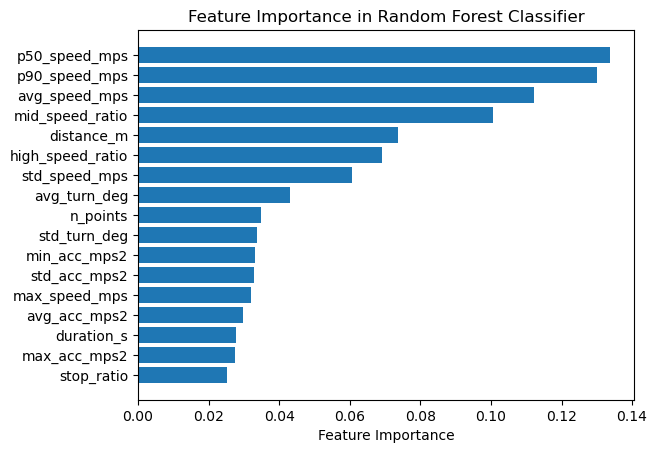

In [5]:
plt.barh(importance_df['Features'], importance_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance in Random Forest Classifier')
plt.show()


### Task 2

#### Random forest

Accuracy: 85.57%
              precision    recall  f1-score   support

        bike       0.92      0.80      0.86       377
         bus       0.81      0.72      0.76       472
         car       0.81      0.77      0.79       340
        walk       0.87      0.96      0.91      1077

    accuracy                           0.86      2266
   macro avg       0.85      0.81      0.83      2266
weighted avg       0.86      0.86      0.85      2266



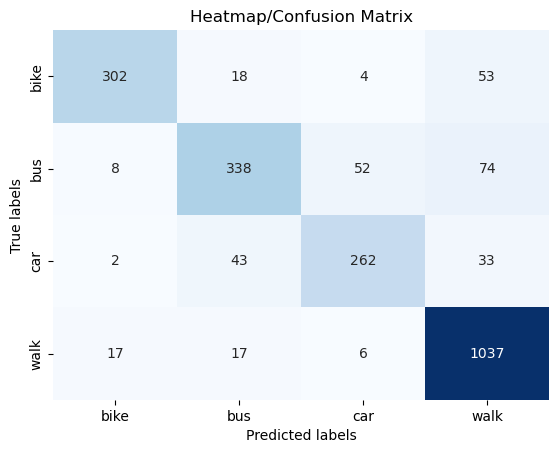

In [6]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

report = classification_report(y_test, y_pred)

print(f'Accuracy: {accuracy * 100:.2f}%')
print(report)

labels = sorted(y.unique())
confusion = confusion_matrix(y_test, y_pred)
sns.heatmap(
  confusion, 
  annot=True,
  fmt='g',
  cmap='Blues',
  cbar=False,
  xticklabels=labels,
  yticklabels=labels
)
plt.title('Heatmap/Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()


#### KNN

KNN Accuracy: 81.47%
              precision    recall  f1-score   support

        bike       0.83      0.82      0.82       377
         bus       0.72      0.64      0.68       472
         car       0.76      0.64      0.70       340
        walk       0.86      0.95      0.90      1077

    accuracy                           0.81      2266
   macro avg       0.79      0.76      0.77      2266
weighted avg       0.81      0.81      0.81      2266



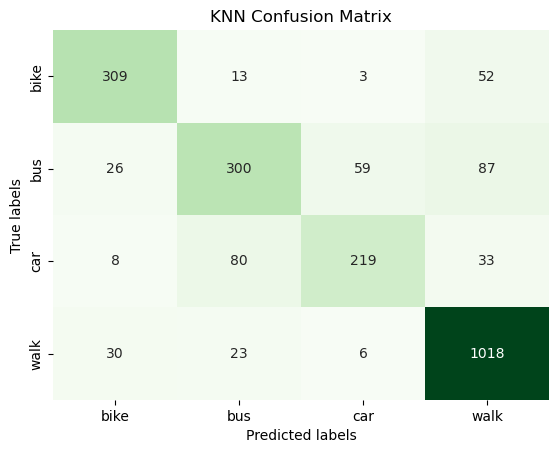

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Skala data (viktigt för KNN då den baseras på avstånd)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Skapa och träna modellen (n_neighbors=5 är standard)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# 3. Gör förutsägelser
y_pred_knn = knn.predict(X_test_scaled)

# 4. Utvärdera resultatet
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f'KNN Accuracy: {accuracy_knn * 100:.2f}%')
print(classification_report(y_test, y_pred_knn))

# 5. Visualisera med Heatmap
sns.heatmap(
    confusion_matrix(y_test, y_pred_knn), 
    annot=True,
    fmt='g',
    cmap='Greens',
    cbar=False,
    xticklabels=labels,
    yticklabels=labels
)
plt.title('KNN Confusion Matrix')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.show()